In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.isnull()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,False,False,False,False,False,False,False,False,False,False,False,False
32577,False,False,False,False,False,False,False,False,False,False,False,False
32578,False,False,False,False,False,False,False,False,False,False,False,False
32579,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
missing=df.isnull().sum()
missing_pct=(missing/len(df))*100

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
loan_int_rate,3116,9.56
person_emp_length,895,2.75


In [14]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [15]:
## Isolate Impossible values
print("Top 10 oldest participants:")
display(df.sort_values('person_age',ascending=False)[['person_age','person_income','person_emp_length','loan_status']].head(10))

print("\n Top 10 longest Employee length")
display(df.sort_values('person_emp_length', ascending=False)[['person_age','person_emp_length','loan_status']].head(10))


Top 10 oldest participants:


,person_age,person_income,person_emp_length,loan_status
81,144,250000,4.0,0
32297,144,6000000,12.0,0
183,144,200000,4.0,0
747,123,78000,7.0,0
575,123,80004,2.0,0
32416,94,24000,1.0,0
32506,84,94800,2.0,0
32422,80,64000,7.0,0
32355,78,48000,41.0,0
32534,76,75000,23.0,0



 Top 10 longest Employee length


,person_age,person_emp_length,loan_status
0,22,123.0,1
210,21,123.0,0
32355,78,41.0,0
32515,53,38.0,0
32428,58,34.0,1
31866,47,31.0,0
32263,46,31.0,0
31867,46,31.0,0
30914,48,31.0,0
32562,61,30.0,0


In [24]:
before=len(df)
## Remove biologically impossibel records
df=df[df['person_age']<=100]
df=df[df['person_emp_length']<=(df['person_age']-14)]


after = len(df)
print(f"Removed {before - after} rows ({(before-after)/before*100:.2f}%) as data entry errors.")
print(f"Remaining rows: {after}")

Removed 0 rows (0.00%) as data entry errors.
Remaining rows: 31679


IQR bounds: [-21,585, 140,951]
Number of income outliers: 1460 (4.61%)


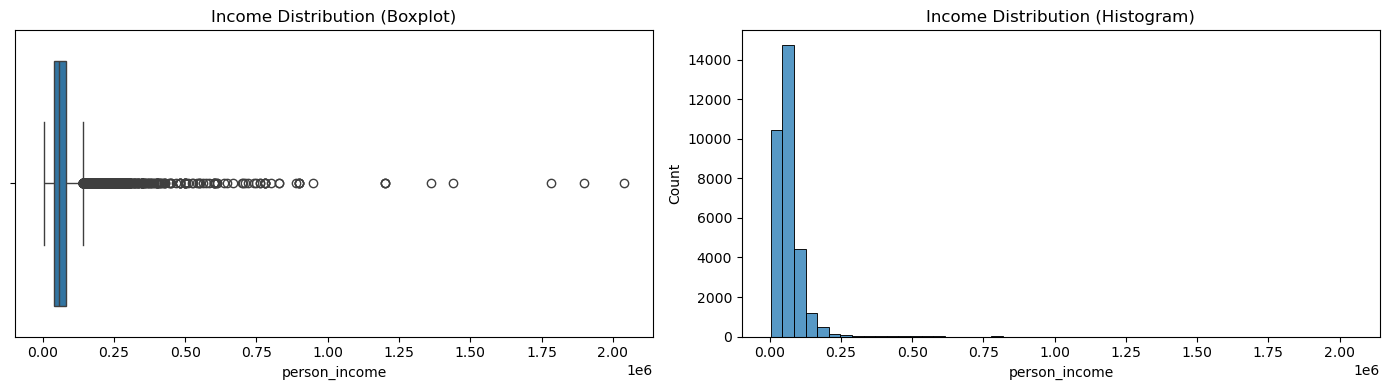

In [27]:
## 8. Outlier Detection on `person_income` — IQR Method
import seaborn as sns
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]
print(f"IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"Number of income outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df['person_income'], ax=axes[0])
axes[0].set_title('Income Distribution (Boxplot)')
sns.histplot(df['person_income'], bins=50, ax=axes[1])
axes[1].set_title('Income Distribution (Histogram)')
plt.tight_layout()
plt.show()

In [28]:
## 9. Duplicate Records Check
dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Exact duplicate rows: 157
Duplicates removed. New shape: (31522, 12)


In [29]:
## . Impute Missing Values
# Impute loan_int_rate by loan_grade median
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'] \
    .transform(lambda x: x.fillna(x.median()))

# Impute person_emp_length with overall median
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Confirm no missing values remain
print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


In [30]:
##  Data Validation Checks
checks = {
    "No missing values": df.isnull().sum().sum() == 0,
    "No duplicate rows": df.duplicated().sum() == 0,
    "All ages between 18-100": df['person_age'].between(18, 100).all(),
    "All loan amounts positive": (df['loan_amnt'] > 0).all(),
    "loan_status only 0 or 1": set(df['loan_status'].unique()).issubset({0, 1}),
    "loan_percent_income between 0 and 1": df['loan_percent_income'].between(0, 1).all(),
}

for check, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {check}")

[PASS] No missing values
[PASS] No duplicate rows
[PASS] All ages between 18-100
[PASS] All loan amounts positive
[PASS] loan_status only 0 or 1
[PASS] loan_percent_income between 0 and 1


In [31]:
##  Final Shape & Export Cleaned Data
df.to_csv('cleaned_loans.csv', index=False)